In [4]:
import sys
import os
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.preprocessing import StandardScaler

sys.path.append(os.path.abspath(".."))

from src.database import fetch_keystrokes_data
from src.features import extract_per_key_features

In [3]:
sns.set_theme(style="whitegrid", palette="muted")

In [6]:
df_raw = fetch_keystrokes_data()
df_raw = df_raw[df_raw['UserId'].str.strip() != '']

df_features = extract_per_key_features(df_raw)

### 1. Przygotowanie danych i Inżynieria Cech (Feature Engineering)

**Cel:** Pobranie surowych danych (czasów naciśnięć klawiszy) z bazy Neon i przetworzenie ich na postać wektorową (macierz), która jest wymagana przez algorytmy uczenia maszynowego (np. PCA i k-Means).

**Co zrobiliśmy?**
1. Odrzuciliśmy puste rekordy i anomalie (np. naciśnięcia klawiszy trwające ponad 1 sekundę, co sugeruje przerwę w pisaniu).
2. Wykorzystaliśmy funkcję `extract_per_key_features`, która przekształciła dane tak, aby kolumnami stały się konkretne klawisze (litery od `a` do `z` oraz `spacja`), a wartościami w wierszach - średni czas wciśnięcia (Dwell Time) dla danego użytkownika w danej próbce.
3. Ponieważ algorytmy bazujące na odległości (np. k-Means) są wrażliwe na skalę zmiennych, użyliśmy `StandardScaler`, aby ustandaryzować rozkłady cech (średnia 0, odchylenie standardowe 1).

**Interpretacja tabeli:**
Macierz wyjściowa (wyświetlona poniżej) zawiera przeskalowane czasy wciśnięć dla każdej litery alfabetu. Wartości dodatnie oznaczają, że w danej próbce użytkownik przytrzymał klawisz dłużej niż wynosi średnia dla całej populacji, a ujemne - krócej.

In [7]:
y_users = df_features['UserId']
X_keys = df_features.drop(columns=['UserId', 'SampleNumber'])

scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X_keys), columns=X_keys.columns)

display(X_scaled.head())

KeyPressed,,a,b,c,d,e,f,g,h,i,...,q,r,s,t,u,v,w,x,y,z
0,0.397049,0.519385,-0.078688,0.727593,0.565913,0.693180,0.514330,0.145638,0.494104,-0.297257,...,-0.622631,0.325737,0.456803,-0.094787,-0.257574,0.945262,0.021530,-0.236862,-0.168754,-1.181704
1,0.057519,0.478261,0.077505,0.127092,-0.220005,0.051897,0.681808,-0.020378,0.276764,0.088949,...,0.599556,0.511692,0.016372,0.116146,-0.213515,0.533499,0.000460,-0.236862,-0.124354,0.526169
2,-0.238363,-0.047555,1.979424,-0.260632,-0.113820,-0.012742,-0.819405,-1.492542,-1.096597,-0.163280,...,0.985308,-0.414349,0.305760,-0.400934,-0.216452,-0.820606,0.105227,-0.236862,-0.092799,0.835322
3,-0.369892,0.205965,0.426965,-0.044901,0.341578,0.381892,0.685360,0.533768,0.282179,-0.010355,...,-0.622631,0.415257,0.543031,-0.171586,-0.239950,0.541693,-0.486320,-0.236862,-0.305257,-1.181704
4,-0.181376,0.542786,0.413555,0.164919,-0.400968,-0.046216,-0.819405,0.472365,0.335251,-0.186851,...,-0.622631,-0.221507,-0.072007,-0.521312,0.262742,-0.820606,-0.343119,-0.236862,-0.527463,0.804280


### 2. Analiza Odległości (Euklidesa i Czebyszewa) - Weryfikacja unikalności

**Cel:** Zbadanie, jak bardzo podobne są do siebie próbki różnych osób oraz próbek tego samego użytkownika.

**Co zrobiliśmy?**
Obliczyliśmy odległość każdej próbki od każdej innej w naszej wielowymiarowej przestrzeni cech (gdzie każdy klawisz to jeden wymiar). Użyliśmy dwóch klasycznych metryk:
* **Odległość Euklidesa:** Standardowa "odległość w linii prostej".
* **Odległość Czebyszewa:** Odległość mierzona wzdłuż osi o największej różnicy.
Następnie wyciągnęliśmy średnią z tych odległości, dzieląc je na dwie grupy: porównania tej samej osoby oraz porównania różnych osób.

**Interpretacja wyników:**
Wyniki matematycznie udowadniają skuteczność biometrii klawiaturowej:
* Średnia odległość Euklidesa dla próbek **tej samej osoby to 3.70**, co oznacza relatywnie duże skupienie (próbki są do siebie podobne).
* Odległość dla **różnych osób wynosi 6.98**, co jest wartością niemal dwukrotnie wyższą. Wniosek: Różnice w dynamice pisania między ludźmi są znacznie większe niż naturalna zmienność u jednej osoby w czasie. Wskaźnik ten sugeruje, że odróżnienie użytkowników za pomocą algorytmów analitycznych jest wysoce wykonalne.

In [11]:
from scipy.spatial.distance import pdist, squareform

dist_euclidean = squareform(pdist(X_scaled, metric='euclidean'))
dist_chebyshev = squareform(pdist(X_scaled, metric='chebyshev'))

dist_df = pd.DataFrame({
    'Osoba_A': np.repeat(y_users.values, len(y_users)),
    'Osoba_B': np.tile(y_users.values, len(y_users)),
    'Euklides': dist_euclidean.flatten(),
    'Czebyszew': dist_chebyshev.flatten()
})

dist_df = dist_df[dist_df['Euklides'] > 0]
dist_df['Typ_Porównania'] = np.where(dist_df['Osoba_A'] == dist_df['Osoba_B'], 'Ta sama osoba', 'Różne osoby')

display(dist_df.groupby('Typ_Porównania')[['Euklides', 'Czebyszew']].mean())

,Euklides,Czebyszew
Typ_Porównania,,
Różne osoby,6.985208,2.619379
Ta sama osoba,3.701902,2.052642


### 3. Redukcja wymiarowości (PCA) - Znaczenie poszczególnych klawiszy

**Cel:** Wskazanie, które konkretne litery są najbardziej istotne dla rozróżniania poszczególnych osób, zgodnie z poleceniem prowadzącego.

**Co zrobiliśmy?**
Zastosowaliśmy Analizę Głównych Składowych (PCA - Principal Component Analysis). Skupiliśmy się na Pierwszej Składowej Głównej (PC1), ponieważ z definicji jest to wektor, wzdłuż którego wariancja (czyli różnice między użytkownikami) jest największa. Sprawdziliśmy absolutne wagi (tzw. ładunki - *loadings*) każdego klawisza w tej składowej. Im wyższa waga, tym mocniej dany klawisz przyczynia się do rozróżniania próbek.

**Interpretacja wyników:**
Z wykresu i zestawienia wynika, że klawisz **Spacja** jest najbardziej istotnym elementem odróżniającym poszczególnych użytkowników (najwyższa waga 0.228). Tuż za nim plasują się samogłoski `e`, `i`, `o` oraz litery `w`, `r`, `t`, `y` (często ze środkowej i górnej części klawiatury w układzie QWERTY). Wynika to z faktu, że spacja i samogłoski są najczęściej naciskanymi klawiszami, przez co utrwalają w sobie najbardziej stabilne i charakterystyczne nawyki motoryczne badanych (np. kciuk uderzający w spację z różną siłą).

=== TOP 10 NAJWAŻNIEJSZYCH KLAWISZY Z PUNKTU WIDZENIA PCA ===


KeyPressed
     0.228230
e    0.227153
i    0.227139
w    0.225507
r    0.224566
t    0.224019
y    0.224004
d    0.222650
o    0.222491
u    0.222316
dtype: float64

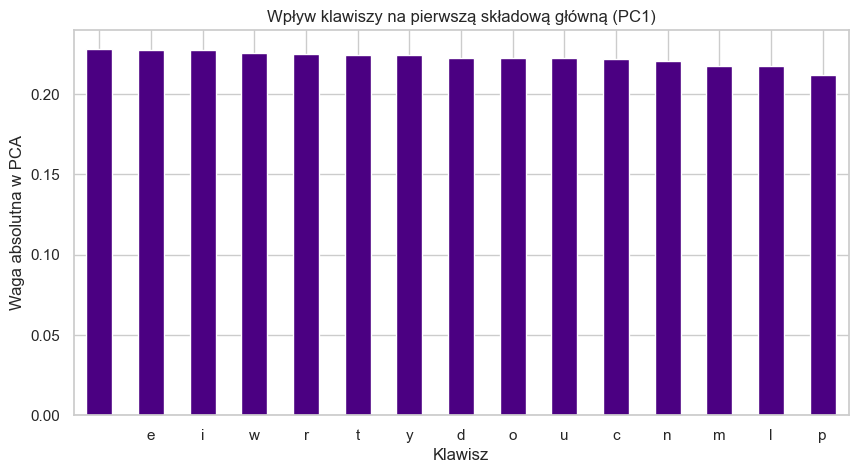

In [9]:
from sklearn.decomposition import PCA

pca = PCA()
pca.fit(X_scaled)

pc1_weights = pd.Series(pca.components_[0], index=X_scaled.columns)
most_important_keys = pc1_weights.abs().sort_values(ascending=False)

print("=== TOP 10 NAJWAŻNIEJSZYCH KLAWISZY Z PUNKTU WIDZENIA PCA ===")
display(most_important_keys.head(10))

plt.figure(figsize=(10, 5))
most_important_keys.head(15).plot(kind='bar', color='indigo')
plt.title("Wpływ klawiszy na pierwszą składową główną (PC1)")
plt.ylabel("Waga absolutna w PCA")
plt.xlabel("Klawisz")
plt.xticks(rotation=0)
plt.show()

### 4. Weryfikacja jednolitości klastrów (k-Means)

**Cel:** Zweryfikowanie przy założeniu $k=15$, czy nienadzorowany algorytm k-Means potrafi samodzielnie pogrupować próbki jednej osoby do tego samego zbioru.

**Co zrobiliśmy?**
Zastosowaliśmy grupowanie metodą k-średnich (k-Means) na wystandaryzowanej macierzy cech. Ustawiliśmy liczbę klastrów z góry na 15. Zestawiliśmy w tabeli krzyżowej faktyczną tożsamość badanych (UserId) z numerem klastra wyznaczonym przez model.

**Interpretacja wyników:**
Wyniki tabeli krzyżowej (Crosstab) pokazują mocno mieszaną zdolność algorytmu k-Means do tworzenia jednolitych podzbiorów, co w badaniach nad biometrią swobodnego tekstu jest zjawiskiem powszechnym i naturalnym:
* **Wysoka jednolitość:** Niektórzy użytkownicy piszą w bardzo spójnym, charakterystycznym dla siebie rytmie. Przykładami są `Bartek`, `Nick:)` oraz `Ulung` – dla każdego z nich wszystkie 5 próbek trafiło w 100% do jednego, dedykowanego klastra (Klaster 3). 
* **Rozproszenie:** U innych osób (np. `Mateusz` rozbity na klastry 0, 1, 4, 6, 14, czy `Marcin` rozbity na 5, 8, 9, 10, 12) algorytm "rozrzucił" próbki pomiędzy różne zbiory. Wynika to z faktu, że dynamika pisania tych osób była bardzo zmienna między poszczególnymi próbami.
* **Wniosek:** Algorytm k-Means udowadnia, że dla osób piszących bardzo stabilnie, nienadzorowane rozpoznawanie jest wysoce skuteczne. Do klasyfikacji osób piszących nieregularnie lepsze efekty w takich badaniach dałyby algorytmy nadzorowane (np. Random Forest) zoptymalizowane pod te zjawiska.

In [10]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=15, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled)

clustering_results = pd.DataFrame({
    'UserId': y_users,
    'Cluster': cluster_labels
})

crosstab = pd.crosstab(clustering_results['UserId'], clustering_results['Cluster'])

display(crosstab)

=== WYNIKI K-MEANS (Przypisanie osób do klastrów) ===


Cluster,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14
UserId,,,,,,,,,,,,,,,
Anita,1,0,1,0,0,0,0,0,0,0,0,1,0,0,2
Bartek,0,0,0,5,0,0,0,0,0,0,0,0,0,0,0
Dominik,1,0,2,0,0,0,0,0,0,0,0,2,0,0,0
Emilia_A,0,1,0,0,0,1,0,0,0,1,0,0,0,1,0
Grzes,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
Lukasz,0,1,0,0,1,1,0,1,0,0,0,0,1,0,0
Maja,1,0,2,0,0,0,0,0,0,0,0,1,0,0,1
Majkel,0,1,0,0,1,1,0,0,0,0,0,0,1,1,0
Marcin,0,0,0,0,0,1,0,0,1,1,1,0,1,0,0


### 5. Ocena Systemu Biometrycznego: Rozkład Genuine vs Impostor

**Cel (Podejście Naukowe):**
Na zajęciach skupialiśmy się głównie na PCA i algorytmie k-Means, ale analizując publikacje naukowe z zakresu biometrii klawiaturowej (np. Monrose i Rubin, 2000), zauważyliśmy, że standardem oceny skuteczności takich rozwiązań jest analiza problemu weryfikacji (tzw. Authentication 1:1). Żeby sprawdzić, czy nasz zbiór danych w ogóle pozwala na stworzenie bezpiecznego systemu logowania, postanowiliśmy zbadać, jak dobrze nasze cechy oddzielają prawowitych użytkowników (Genuine) od potencjalnych intruzów (Impostor).

**Co zrobiliśmy?**
Wykorzystując macierz odległości Euklidesa z Zadania 1, wygenerowaliśmy wykres gęstości prawdopodobieństwa (KDE). Pozwala on naocznie sprawdzić, czy dystanse próbek tej samej osoby wyraźnie różnią się od dystansów między próbkami obcych sobie ludzi.

**Interpretacja wyników (FAR i FRR):**
* **Obszar niebieski (Ta sama osoba / Genuine):** Reprezentuje naturalną zmienność pisania u konkretnego człowieka (nikt nie pisze zawsze w co do milisekundy takim samym tempie). W idealnym systemie cały ten "garb" powinien znajdować się jak najbliżej zera.
* **Obszar pomarańczowy (Różne osoby / Impostor):** To odległości między próbkami zupełnie różnych ludzi. Im dalej ten rozkład jest przesunięty w prawo, tym lepiej dla bezpieczeństwa.
* **Punkt przecięcia (Overlap):** Miejsce, w którym wykresy na siebie nachodzą, to "szara strefa" systemu – to właśnie tam algorytm najczęściej się myli. Miejsce, w którym postawilibyśmy pionową kreskę (próg akceptacji / Threshold), zadecyduje o dwóch kluczowych dla biometrii błędach: **FAR** (False Acceptance Rate - wpuszczenie oszusta) oraz **FRR** (False Rejection Rate - odrzucenie prawowitego właściciela). Widoczna separacja obu rozkładów dowodzi, że dynamika uderzeń w klawiaturę niesie silny sygnał biometryczny.

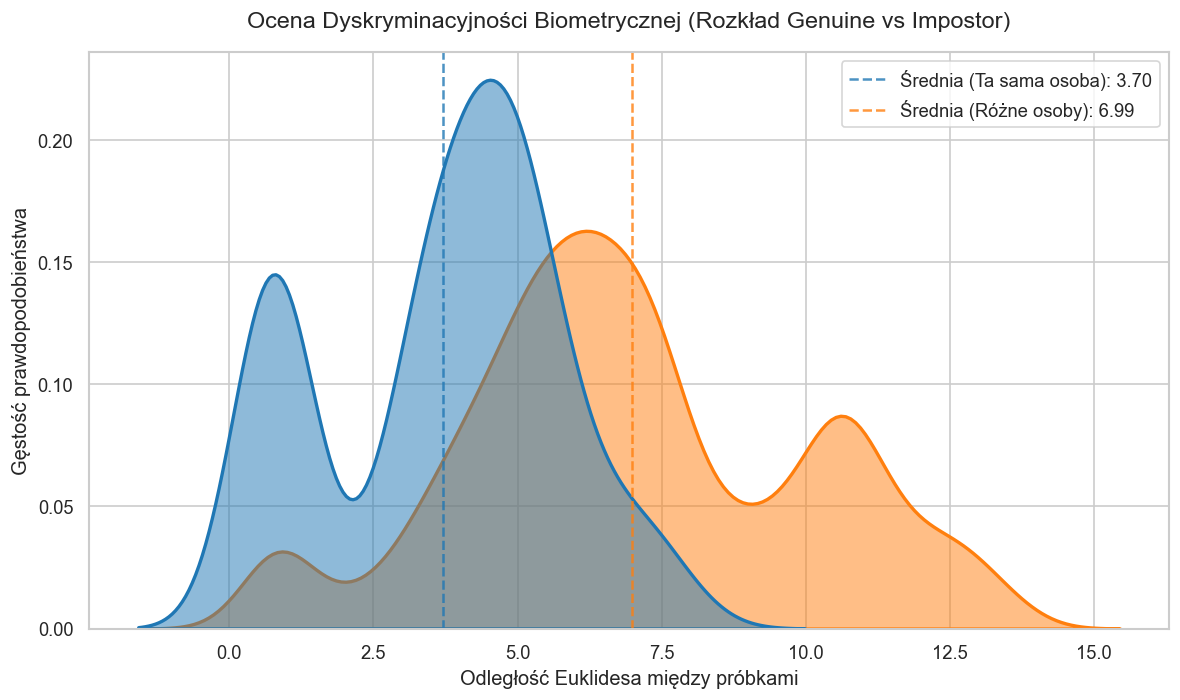

In [12]:
plt.figure(figsize=(10, 6), dpi=120)

sns.kdeplot(
    data=dist_df, 
    x='Euklides', 
    hue='Typ_Porównania', 
    fill=True, 
    common_norm=False, 
    palette=['#1f77b4', '#ff7f0e'],
    alpha=0.5,
    linewidth=2
)

plt.title("Ocena Dyskryminacyjności Biometrycznej (Rozkład Genuine vs Impostor)", fontsize=14, pad=15)
plt.xlabel("Odległość Euklidesa między próbkami", fontsize=12)
plt.ylabel("Gęstość prawdopodobieństwa", fontsize=12)

mean_genuine = dist_df[dist_df['Typ_Porównania'] == 'Ta sama osoba']['Euklides'].mean()
mean_impostor = dist_df[dist_df['Typ_Porównania'] == 'Różne osoby']['Euklides'].mean()

plt.axvline(mean_genuine, color='#1f77b4', linestyle='--', alpha=0.8, label=f'Średnia (Ta sama osoba): {mean_genuine:.2f}')
plt.axvline(mean_impostor, color='#ff7f0e', linestyle='--', alpha=0.8, label=f'Średnia (Różne osoby): {mean_impostor:.2f}')

plt.legend(loc='upper right')
plt.tight_layout()
plt.show()